# Calculation and Visualisation of Results Metrics

In [1]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
import pandas as pd

In [2]:
# ── load and join results and gorund truth ───────────────────────────────────────────────
df_gt = pd.read_csv("../data/csv/roberta_labelled/tuned_test_modifiedprompt_8.csv")
df_base = pd.read_csv("../data/csv/roberta_labelled/base_test_labeled_8.csv")
df_tuned = pd.read_csv("../data/csv/roberta_labelled/tuned_test_labeled_8.csv")

df_gt = df_gt.rename(columns = {"labels": "label"})
df_gt["idx"] = df_gt.index


In [ ]:
df_base  = df_base.merge(df_gt[["idx", "label"]], on="idx", suffixes=("_pred", "_true"))
df_tuned = df_tuned.merge(df_gt[["idx", "label"]], on="idx", suffixes=("_pred", "_true"))

In [4]:
DIMENSIONS = ["I", "N", "F", "P"]
PAIRS = {"I": ("I","E"), "N": ("N","S"), "F": ("F","T"), "P": ("P","J")}
THRESHOLDS = {"I": 0.71, "N": 0.61, "F": 0.62, "P": 0.63}

In [5]:
y_true_base  = df_base["label_true"].tolist()
y_pred_base  = df_base["label_pred"].tolist()
y_true_tuned = df_tuned["label_true"].tolist()
y_pred_tuned = df_tuned["label_pred"].tolist()

# ── Macro F1 ──────────────────────────────────────────────────────────────────
f1_base  = f1_score(y_true_base,  y_pred_base,  average="macro", zero_division=0)
f1_tuned = f1_score(y_true_tuned, y_pred_tuned, average="macro", zero_division=0)
print(f"Macro F1  — Base:  {f1_base:.4f}")
print(f"Macro F1  — Tuned: {f1_tuned:.4f}")

# ── Per-Dimension F1 & Accuracy ───────────────────────────────────────────────
for dim, (pos, neg) in PAIRS.items():
    # Binarize: positive class = pos-letter (z.B. 'I', 'N', 'F', 'P')
    def binarize(labels, pos):
        return [1 if l[DIMENSIONS.index(dim)] == pos else 0 for l in labels]

    yb_true  = binarize(y_true_base,  pos)
    yb_pred  = binarize(y_pred_base,  pos)
    yt_true  = binarize(y_true_tuned, pos)
    yt_pred  = binarize(y_pred_tuned, pos)

    f1_b = f1_score(yb_true, yb_pred, average="binary", zero_division=0)
    f1_t = f1_score(yt_true, yt_pred, average="binary", zero_division=0)
    ac_b = accuracy_score(yb_true, yb_pred)
    ac_t = accuracy_score(yt_true, yt_pred)
    print(f"\n[{dim}]  Base  → F1: {f1_b:.4f}  Acc: {ac_b:.4f}")
    print(f"[{dim}]  Tuned → F1: {f1_t:.4f}  Acc: {ac_t:.4f}")

# ── Mcnemars's Test (base vs. tuned, per sample correct/wrong) ────────────────
correct_base  = [p == t for p, t in zip(y_pred_base,  y_true_base)]
correct_tuned = [p == t for p, t in zip(y_pred_tuned, y_true_tuned)]

# Contingency table: [[both correct, only base correct], [only tuned correct, both wrong]]
b = sum(1 for cb, ct in zip(correct_base, correct_tuned) if cb and not ct)
c = sum(1 for cb, ct in zip(correct_base, correct_tuned) if not cb and ct)
table = [[sum(1 for cb, ct in zip(correct_base, correct_tuned) if cb and ct),  b],
         [c, sum(1 for cb, ct in zip(correct_base, correct_tuned) if not cb and not ct)]]

result = mcnemar(table, exact=False, correction=True)  
print(f"\nMcNemar's Test: χ²={result.statistic:.4f}, p={result.pvalue:.4f}")
print("→ Signifikant (p<0.05):" , result.pvalue < 0.05)

# ── Confusion matrix (16 MBTI types) ─────────────────────────────────────────
all_types = sorted(set(y_true_base + y_pred_base + y_true_tuned + y_pred_tuned))

cm_base  = confusion_matrix(y_true_base,  y_pred_base,  labels=all_types)
cm_tuned = confusion_matrix(y_true_tuned, y_pred_tuned, labels=all_types)

print("\nKonfusionsmatrix Base:")
print(pd.DataFrame(cm_base,  index=all_types, columns=all_types))
print("\nKonfusionsmatrix Tuned:")
print(pd.DataFrame(cm_tuned, index=all_types, columns=all_types))

Macro F1  — Base:  0.2156
Macro F1  — Tuned: 0.0856

[I]  Base  → F1: 0.7346  Acc: 0.6450
[I]  Tuned → F1: 0.6048  Acc: 0.5262

[N]  Base  → F1: 0.7357  Acc: 0.6650
[N]  Tuned → F1: 0.5181  Acc: 0.5675

[F]  Base  → F1: 0.7598  Acc: 0.6863
[F]  Tuned → F1: 0.6896  Acc: 0.6050

[P]  Base  → F1: 0.7949  Acc: 0.7987
[P]  Tuned → F1: 0.6717  Acc: 0.5637

McNemar's Test: χ²=50.7735, p=0.0000
→ Signifikant (p<0.05): True

Konfusionsmatrix Base:
      ENFJ  ENFP  ENTJ  ENTP  ESFJ  ESFP  ESTJ  ESTP  INFJ  INFP  INTJ  INTP  \
ENFJ     6     1     0     0     1     0     0     0    26    11     0     0   
ENFP     0    14     0     0     0     0     0     0     2    30     0     1   
ENTJ    11     4     7     2     2     0     0     0    10     6     3     0   
ENTP     1    20     0     1     0     0     0     1     3    22     0     1   
ESFJ     5     0     0     0     0     0     0     0    27     1     0     0   
ESFP     2    16     0     1     1     5     0     0     3    14     0     0 

In [6]:
pd.set_option('display.max_colwidth', None)
print(df_base["text"].head(5).to_string())
print(df_tuned["text"].head(5).to_string())

0                                                                                                                                                                                                                                        Last weekend, I spent most of the time at home. On Saturday, I went to the local library to help my cousin with some homework. We worked on a history project together; it was nice to catch up while we were there. In the evening, I baked some cookies—chocolate chip, of course. It's one of my favorite things to do. On Sunday, I stayed in and watched a few old movies. I found a classic film series that I hadn't seen before, and it was really enjoyable. Overall, it was a cozy weekend, just how I like them.
1    Last weekend, I spent a lot of time at the office finishing up some projects that were due on Monday. On Saturday, I went grocery shopping in the morning and then spent the afternoon helping my cousin move to a new apartment. We got a late start but mana

In [7]:
print("Base label distribution:")
print(df_base["label_pred"].value_counts())

print("\nTuned label distribution:")
print(df_tuned["label_pred"].value_counts())

Base label distribution:
label_pred
INFJ    220
INFP    173
ISFJ     90
INTP     69
ENFP     68
ISFP     49
INTJ     39
ENFJ     30
ISTJ     20
ISTP     10
ESFJ      8
ENTJ      8
ESFP      7
ENTP      7
ESTP      2
Name: count, dtype: int64

Tuned label distribution:
label_pred
ISFP    214
INFP    125
ESFP     94
ENFP     74
ISTP     67
ISFJ     60
INTP     49
ENTP     29
INFJ     22
ESFJ     20
ISTJ     13
ESTP     11
ENFJ      9
INTJ      9
ESTJ      3
ENTJ      1
Name: count, dtype: int64


In [8]:
print("Ground Truth distribution:")
print(df_base["label_true"].value_counts())

Ground Truth distribution:
label_true
ISFJ    50
ESTJ    50
ISFP    50
INTJ    50
ESTP    50
ENTP    50
INFP    50
ENTJ    50
ESFP    50
ISTP    50
ESFJ    50
ENFP    50
INFJ    50
ISTJ    50
ENFJ    50
INTP    50
Name: count, dtype: int64


In [9]:
print("\n── McNemar per dimension ──────────────────────────────────────────────")
for dim, (pos, neg) in PAIRS.items():
    def binarize(labels, pos):
        return [1 if l[DIMENSIONS.index(dim)] == pos else 0 for l in labels] # returns 1 for positive (correct) values and 0 for negative (incorrect)
    
    yb_true = binarize(y_true_base,  pos) # base ground truth
    yb_pred = binarize(y_pred_base,  pos) # base predictions
    yt_true = binarize(y_true_tuned, pos) # tuned ground truth
    yt_pred = binarize(y_pred_tuned, pos) # tuned predicitons
    
    # True or False list for base and tuned model
    # zip creates pairs per obs, which are looped trhough with p and t, and then p == t gets tested
    correct_b = [p == t for p, t in zip(yb_pred, yb_true)]
    correct_t = [p == t for p, t in zip(yt_pred, yt_true)]
    
    # b_d --> base model correctly predicted, tuned not; c_d --> other way around
    b_d = sum(1 for cb, ct in zip(correct_b, correct_t) if cb and not ct)
    c_d = sum(1 for cb, ct in zip(correct_b, correct_t) if not cb and ct)
    
    # contingency table
    table_d = [
        [sum(1 for cb, ct in zip(correct_b, correct_t) if cb and ct),  b_d],
        [c_d, sum(1 for cb, ct in zip(correct_b, correct_t) if not cb and not ct)]
    ]
    res = mcnemar(table_d, exact=False, correction=True)
    sig = "✓" if res.pvalue < 0.0125 else "✗"  # Bonferroni
    print(f"[{dim}]  χ²={res.statistic:.4f}  p={res.pvalue:.4f}  sig(α=.0125): {sig}")


── McNemar per dimension ──────────────────────────────────────────────
[I]  χ²=30.5744  p=0.0000  sig(α=.0125): ✓
[N]  χ²=14.5319  p=0.0001  sig(α=.0125): ✓
[F]  χ²=17.7316  p=0.0000  sig(α=.0125): ✓
[P]  χ²=91.5419  p=0.0000  sig(α=.0125): ✓


In [10]:
print(table_d)

[[354, 285], [97, 64]]


In [10]:
df_base["text_length"] = df_base["text"].str.split().str.len()
df_tuned["text_length"] = df_tuned["text"].str.split().str.len()

print("Base mean length:", df_base["text_length"].mean())
print("Tuned mean length:", df_tuned["text_length"].mean())

Base mean length: 101.98125
Tuned mean length: 90.67


Saved: confusion_prompt2.pdf


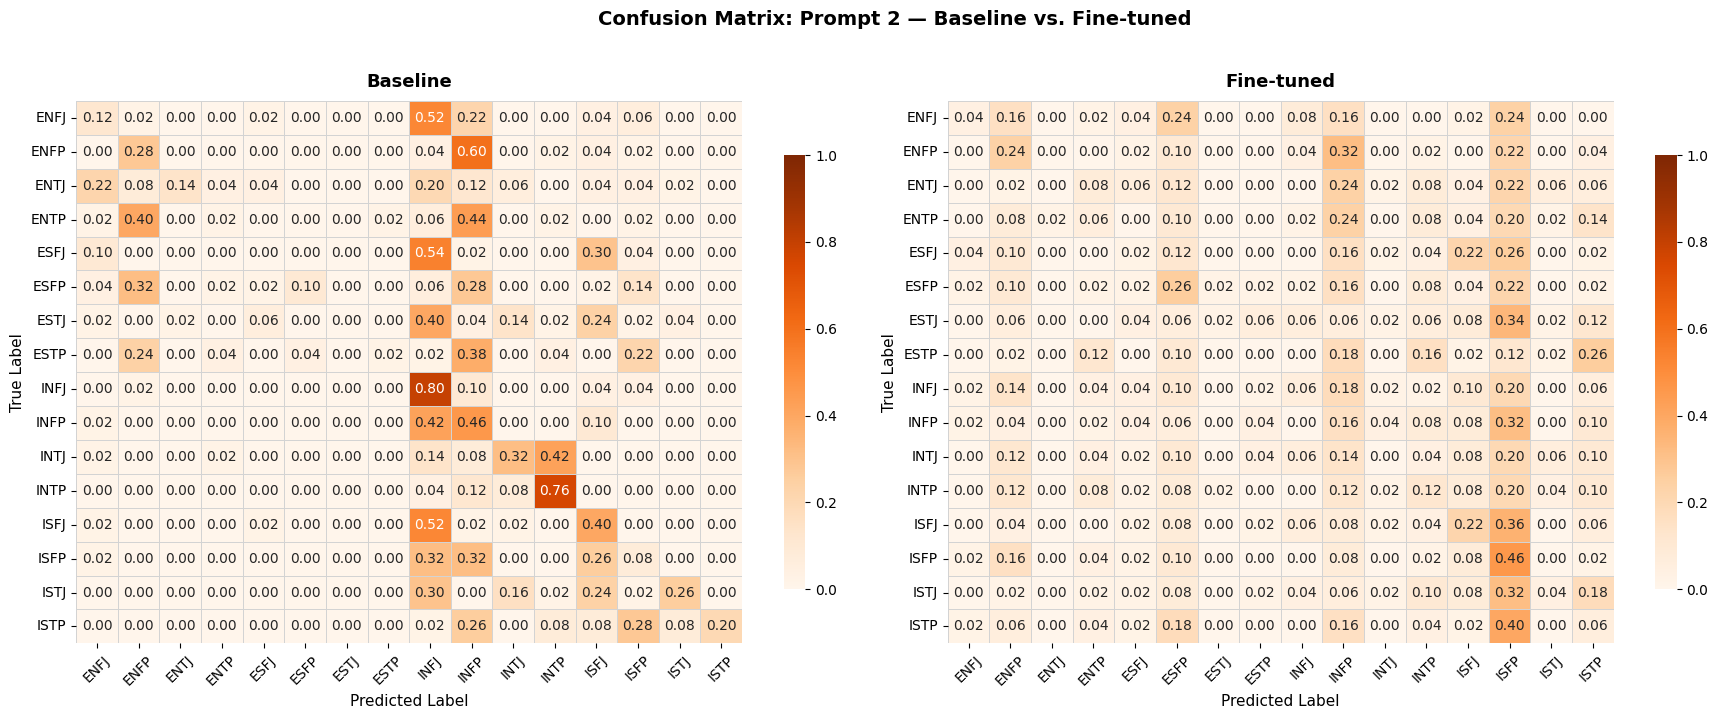

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

all_types = sorted(set(y_true_base + y_pred_base + y_true_tuned + y_pred_tuned))

def plot_confusion_heatmap(y_true_b, y_pred_b, y_true_t, y_pred_t, title, filename):
    cm_base  = confusion_matrix(y_true_b, y_pred_b,  labels=all_types)
    cm_tuned = confusion_matrix(y_true_t, y_pred_t, labels=all_types)
    
    # Zeilennormalisierung (recall per class)
    cm_base_norm  = cm_base.astype(float)  / cm_base.sum(axis=1, keepdims=True).clip(min=1)
    cm_tuned_norm = cm_tuned.astype(float) / cm_tuned.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    for ax, cm, model_name in zip(axes, [cm_base_norm, cm_tuned_norm], ["Baseline", "Fine-tuned"]):
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap="Oranges",
            xticklabels=all_types,
            yticklabels=all_types,
            vmin=0, vmax=1,
            linewidths=0.4,
            linecolor="lightgrey",
            ax=ax,
            cbar_kws={"shrink": 0.8}
        )
        ax.set_title(f"{model_name}", fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label", fontsize=11)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    #plt.savefig(filename, dpi=300, bbox_inches="tight")
    #plt.close()
    
    print(f"Saved: {filename}")

# Prompt 2 (Haupttext)
plot_confusion_heatmap(
    y_true_base, y_pred_base, y_true_tuned, y_pred_tuned,
    title="Confusion Matrix: Prompt 2 — Baseline vs. Fine-tuned",
    filename="confusion_prompt2.pdf"
)

# # Prompt 1 (Appendix)
# plot_confusion_heatmap(
#     y_true_base_p1, y_pred_base_p1, y_true_tuned_p1, y_pred_tuned_p1,
#     title="Confusion Matrix: Prompt 1 — Baseline vs. Fine-tuned",
#     filename="confusion_prompt1.pdf"
# )

# # Prompt 3 (Appendix)
# plot_confusion_heatmap(
#     y_true_base_p3, y_pred_base_p3, y_true_tuned_p3, y_pred_tuned_p3,
#     title="Confusion Matrix: Prompt 3 — Baseline vs. Fine-tuned",
#     filename="confusion_prompt3.pdf"
# )

Saved: ../figs/dconfusion_dim_prompt3.png


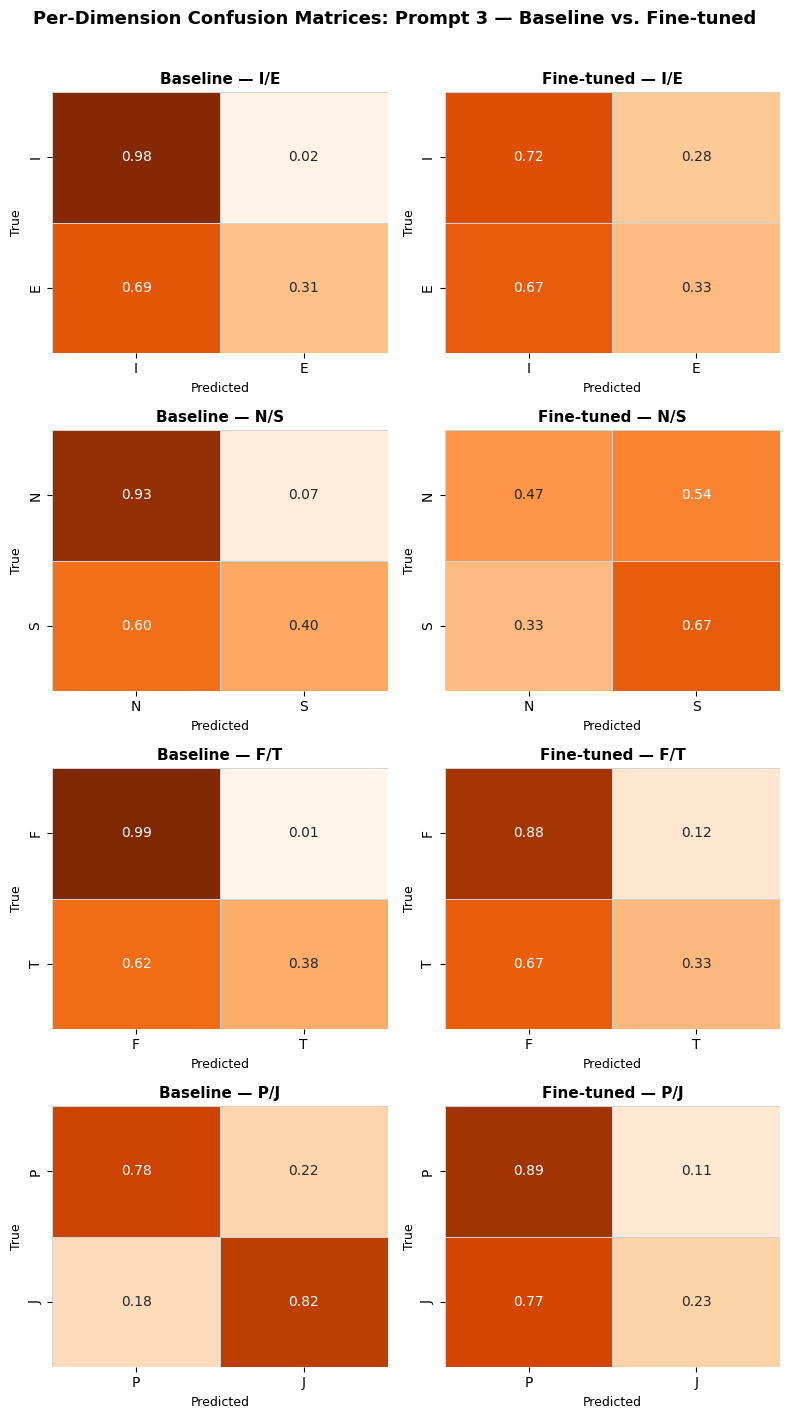

In [24]:
DIM_INDEX = {"I": 0, "N": 1, "F": 2, "P": 3}

def plot_dim_confusion(y_true_b, y_pred_b, y_true_t, y_pred_t, title, filename):
    fig, axes = plt.subplots(4, 2, figsize=(8, 14))

    for row, (dim, (pos, neg)) in enumerate(PAIRS.items()):
        i = DIM_INDEX[dim]
        
        for col, (y_true, y_pred, model_name) in enumerate([
            (y_true_b, y_pred_b, "Baseline"),
            (y_true_t, y_pred_t, "Fine-tuned")
        ]):
            # Binarize
            yt = [1 if l[i] == pos else 0 for l in y_true]
            yp = [1 if l[i] == pos else 0 for l in y_pred]
            
            cm = confusion_matrix(yt, yp, labels=[1, 0])
            cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
            
            ax = axes[row, col]
            sns.heatmap(
                cm_norm,
                annot=True,
                fmt=".2f",
                cmap="Oranges",
                vmin=0, vmax=1,
                xticklabels=[pos, neg],
                yticklabels=[pos, neg],
                linewidths=0.5,
                linecolor="lightgrey",
                cbar=False,
                ax=ax
            )
            ax.set_title(f"{model_name} — {pos}/{neg}", fontsize=11, fontweight="bold")
            ax.set_xlabel("Predicted", fontsize=9)
            ax.set_ylabel("True", fontsize=9)
    
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    #plt.close()
    print(f"Saved: {filename}")

# Prompt 2 (Haupttext)
plot_dim_confusion(
    y_true_base, y_pred_base, y_true_tuned, y_pred_tuned,
    title="Per-Dimension Confusion Matrices: Prompt 3 — Baseline vs. Fine-tuned",
    filename="../figs/dconfusion_dim_prompt3.png"
)